<a href="https://colab.research.google.com/github/dkumar-tech/desktop-tutorial/blob/main/CSVGenProcess.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Generate Telco OSS Alarms Data

First, let's create a synthetic dataset of telco OSS alarms. This dataset will include various columns relevant to alarm monitoring, such as timestamp, alarm ID, severity, affected component, and a description. We will generate 100 rows of data.

In [4]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Set a seed for reproducibility
np.random.seed(42)

# Number of alarms to generate
num_alarms = 100

# Generate timestamps
start_time = datetime(2023, 10, 1, 8, 0, 0)
end_time = datetime(2023, 10, 3, 18, 0, 0)
time_diff = (end_time - start_time).total_seconds()
timestamps = [start_time + timedelta(seconds=np.random.randint(time_diff)) for _ in range(num_alarms)]

# Generate alarm IDs
alarm_ids = [f'ALARM-{i:05d}' for i in range(1, num_alarms + 1)]

# Generate severity levels
severity_options = ['Critical', 'Major', 'Minor', 'Warning', 'Informational']
severities = np.random.choice(severity_options, num_alarms, p=[0.1, 0.2, 0.3, 0.25, 0.15])

# Generate component types
component_options = ['RAN', 'Core', 'Transport', 'Access', 'Power_Supply', 'Software']
components = np.random.choice(component_options, num_alarms)

# Generate descriptions
description_templates = [
    'Link down on {component} interface',
    'High CPU utilization on {component} server',
    'Memory alarm on {component} unit',
    'Packet loss detected on {component} path',
    'Temperature sensor critical on {component} rack',
    'Software error in {component} module',
    'Power failure in {component} cabinet',
    'Service degradation in {component} region'
]
descriptions = [template.format(component=comp) for template, comp in zip(np.random.choice(description_templates, num_alarms), components)]

# Generate status
status_options = ['Active', 'Cleared']
# More active alarms initially, some cleared randomly
statuses = np.random.choice(status_options, num_alarms, p=[0.7, 0.3])

# Generate duration (in seconds)
durations = np.random.randint(60, 3600, num_alarms) # 1 minute to 1 hour

# Generate categories
category_options = [
    'Network Connectivity',
    'Performance Issue',
    'Hardware Failure',
    'Software Glitch',
    'Environmental',
    'Power Outage'
]
categories = np.random.choice(category_options, num_alarms)

# Generate location details
location_options = ['New York', 'London', 'Tokyo', 'Paris', 'Sydney', 'Mumbai']
locations = np.random.choice(location_options, num_alarms)

# Generate node details
node_options = [f'Node-{i:03d}' for i in range(1, 21)] # 20 different nodes
nodes = np.random.choice(node_options, num_alarms)

# Create DataFrame
alarms_df = pd.DataFrame({
    'timestamp': timestamps,
    'alarm_id': alarm_ids,
    'severity': severities,
    'component': components,
    'description': descriptions,
    'status': statuses,
    'duration_seconds': durations,
    'category': categories,
    'location': locations, # Added location
    'node': nodes          # Added node
})

# Sort by timestamp
alarms_df = alarms_df.sort_values(by='timestamp').reset_index(drop=True)

# Save to CSV
csv_file_path = 'telco_oss_alarms.csv'
alarms_df.to_csv(csv_file_path, index=False)

print(f"Generated {num_alarms} alarms and saved to '{csv_file_path}'")

Generated 100 alarms and saved to 'telco_oss_alarms.csv'


Here are the first 5 rows of the generated alarms data:

In [5]:
display(alarms_df.head())

,timestamp,alarm_id,severity,component,description,status,duration_seconds,category,location,node
0,2023-10-01 08:12:49,ALARM-00020,Critical,Core,Temperature sensor critical on Core rack,Active,2203,Hardware Failure,New York,Node-006
1,2023-10-01 08:16:56,ALARM-00091,Informational,Power_Supply,Service degradation in Power_Supply region,Active,1257,Environmental,Tokyo,Node-012
2,2023-10-01 08:45:47,ALARM-00037,Critical,RAN,Temperature sensor critical on RAN rack,Active,1425,Hardware Failure,Tokyo,Node-003
3,2023-10-01 09:04:50,ALARM-00052,Informational,Transport,Service degradation in Transport region,Active,3515,Environmental,London,Node-014
4,2023-10-01 09:28:31,ALARM-00025,Informational,RAN,Temperature sensor critical on RAN rack,Cleared,3500,Hardware Failure,Tokyo,Node-016


### LLM Processing for Root Cause Analysis (RCA)

Now, let's prepare the data for an LLM to perform Root Cause Analysis. We will load the generated CSV file and create a consolidated text field for each alarm, combining relevant information into a single prompt string.

In [7]:
# Load the generated CSV file
alarms_df = pd.read_csv('telco_oss_alarms.csv')

# Display the first few rows to confirm loading
print("Loaded alarms_df:")
display(alarms_df.head())

# Prepare data for LLM by creating a consolidated text field
alarms_df['llm_input_text'] = alarms_df.apply(
    lambda row: f"Alarm ID: {row['alarm_id']}. Timestamp: {row['timestamp']}. Severity: {row['severity']}. Component: {row['component']}. Location: {row['location']}. Node: {row['node']}. Category: {row['category']}. Description: {row['description']}. Status: {row['status']}. Duration: {row['duration_seconds']} seconds.",
    axis=1
)

print("\nFirst 2 LLM input texts generated:")
for i in range(min(2, len(alarms_df))):
    print(f"---\n{alarms_df.loc[i, 'llm_input_text']}\n---")


Loaded alarms_df:


,timestamp,alarm_id,severity,component,description,status,duration_seconds,category,location,node
0,2023-10-01 08:12:49,ALARM-00020,Critical,Core,Temperature sensor critical on Core rack,Active,2203,Hardware Failure,New York,Node-006
1,2023-10-01 08:16:56,ALARM-00091,Informational,Power_Supply,Service degradation in Power_Supply region,Active,1257,Environmental,Tokyo,Node-012
2,2023-10-01 08:45:47,ALARM-00037,Critical,RAN,Temperature sensor critical on RAN rack,Active,1425,Hardware Failure,Tokyo,Node-003
3,2023-10-01 09:04:50,ALARM-00052,Informational,Transport,Service degradation in Transport region,Active,3515,Environmental,London,Node-014
4,2023-10-01 09:28:31,ALARM-00025,Informational,RAN,Temperature sensor critical on RAN rack,Cleared,3500,Hardware Failure,Tokyo,Node-016



First 2 LLM input texts generated:
---
Alarm ID: ALARM-00020. Timestamp: 2023-10-01 08:12:49. Severity: Critical. Component: Core. Location: New York. Node: Node-006. Category: Hardware Failure. Description: Temperature sensor critical on Core rack. Status: Active. Duration: 2203 seconds.
---
---
Alarm ID: ALARM-00091. Timestamp: 2023-10-01 08:16:56. Severity: Informational. Component: Power_Supply. Location: Tokyo. Node: Node-012. Category: Environmental. Description: Service degradation in Power_Supply region. Status: Active. Duration: 1257 seconds.
---


### Placeholder for LLM Integration

Below is a conceptual function `call_llm_for_rca` that mimics an interaction with an LLM for Root Cause Analysis. In a real-world scenario, you would replace this with actual API calls to a chosen LLM (e.g., Google's Gemini API, OpenAI's GPT, etc.).

In [8]:
def call_llm_for_rca(alarm_text):
    """
    Placeholder function to simulate an LLM call for Root Cause Analysis.
    In a real scenario, this would make an API call to an actual LLM.
    """
    # Simulate a brief delay for API call
    # import time
    # time.sleep(0.5)

    # Generate a dummy RCA response based on keywords
    if 'CPU utilization' in alarm_text:
        rca = "High CPU utilization detected. Possible root causes include process overload or misconfigured application. Investigate active processes and resource limits."
    elif 'Memory alarm' in alarm_text:
        rca = "Memory alarm triggered. Likely due to memory leak in a service or excessive memory allocation. Check application logs for memory-related errors and review memory usage."
    elif 'Link down' in alarm_text:
        rca = "Network link down. Could be a physical cable issue, faulty port, or configuration error. Verify physical connectivity and port status."
    elif 'Power failure' in alarm_text:
        rca = "Power failure detected. Check power supply units, circuit breakers, and facility power. Confirm redundant power sources are active."
    elif 'Service degradation' in alarm_text:
        rca = "Service degradation. Could be a cascading failure from another component, network congestion, or application performance issue. Correlate with other alarms and performance metrics."
    else:
        rca = "Generic alarm. Further investigation needed. Check logs and related system metrics for anomalies."

    return f"[Simulated RCA]: {rca}"

# Apply the placeholder LLM function to the 'llm_input_text' column
alarms_df['rca_llm_response'] = alarms_df['llm_input_text'].apply(call_llm_for_rca)

print("First 2 alarms with simulated LLM RCA response:")
for i in range(min(2, len(alarms_df))):
    print(f"---\nAlarm Text: {alarms_df.loc[i, 'llm_input_text']}\nSimulated RCA: {alarms_df.loc[i, 'rca_llm_response']}\n---")

First 2 alarms with simulated LLM RCA response:
---
Alarm Text: Alarm ID: ALARM-00020. Timestamp: 2023-10-01 08:12:49. Severity: Critical. Component: Core. Location: New York. Node: Node-006. Category: Hardware Failure. Description: Temperature sensor critical on Core rack. Status: Active. Duration: 2203 seconds.
Simulated RCA: [Simulated RCA]: Generic alarm. Further investigation needed. Check logs and related system metrics for anomalies.
---
---
Alarm Text: Alarm ID: ALARM-00091. Timestamp: 2023-10-01 08:16:56. Severity: Informational. Component: Power_Supply. Location: Tokyo. Node: Node-012. Category: Environmental. Description: Service degradation in Power_Supply region. Status: Active. Duration: 1257 seconds.
Simulated RCA: [Simulated RCA]: Service degradation. Could be a cascading failure from another component, network congestion, or application performance issue. Correlate with other alarms and performance metrics.
---


### Alarm Visualization and Dashboard

Now, let's visualize the alarm data to understand its distribution, trends, and categories. We will use `matplotlib` and `seaborn` to create several dashboard-like plots.

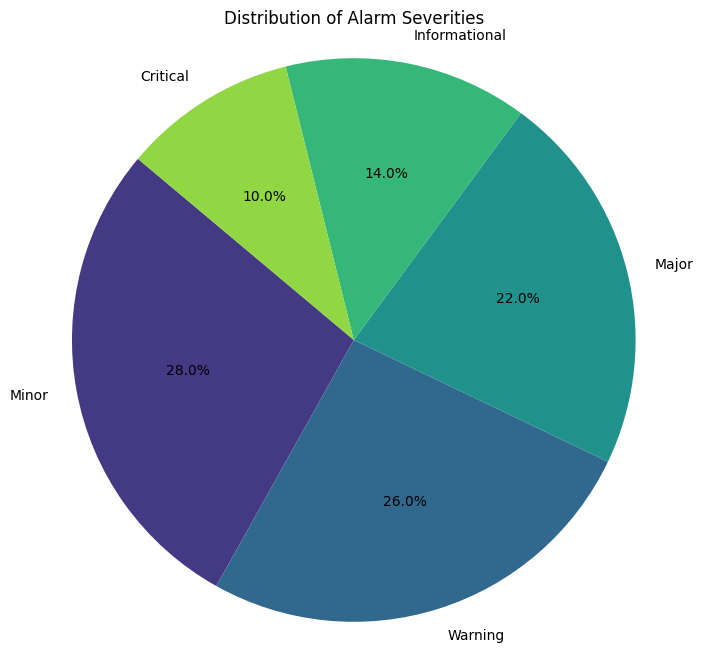

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'timestamp' column is in datetime format
alarms_df['timestamp'] = pd.to_datetime(alarms_df['timestamp'])

# 1. Alarm Severity Distribution (Pie Chart)
plt.figure(figsize=(8, 8))
severity_counts = alarms_df['severity'].value_counts()
plt.pie(severity_counts, labels=severity_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(severity_counts)))
plt.title('Distribution of Alarm Severities')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

This pie chart shows the percentage distribution of different alarm severity levels, giving you an immediate overview of how critical your alarms are.

/tmp/ipykernel_9782/1151564689.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='component', data=alarms_df, order=alarms_df['component'].value_counts().index, palette='magma')


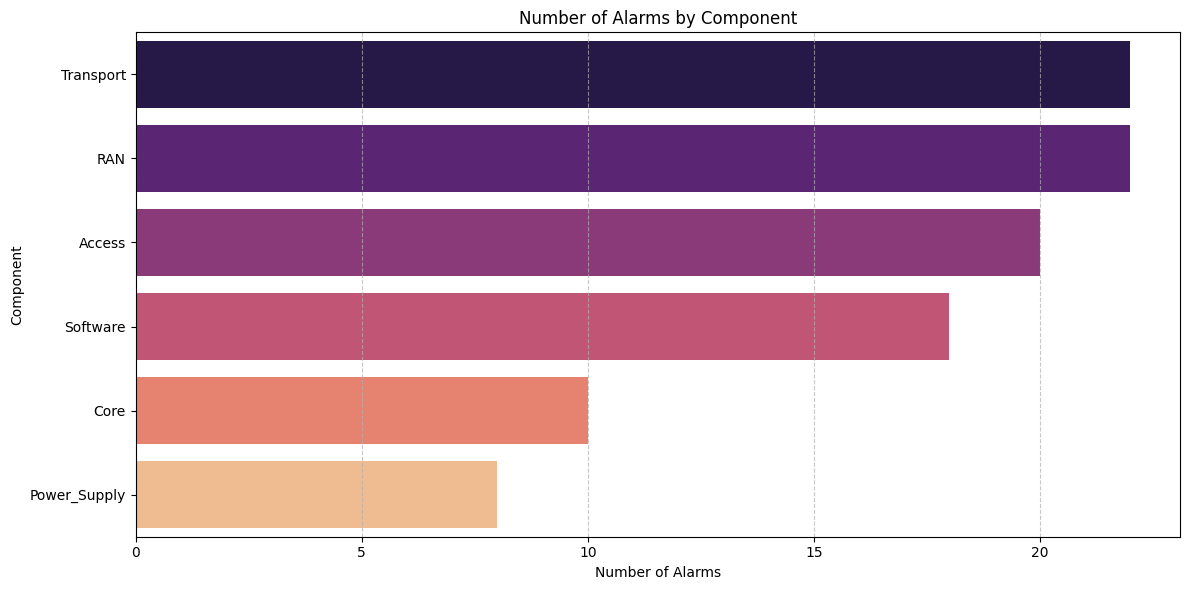

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'timestamp' column is in datetime format (if not already done)
alarms_df['timestamp'] = pd.to_datetime(alarms_df['timestamp'])

# 2. Alarms by Component (Bar Chart)
plt.figure(figsize=(12, 6))
sns.countplot(y='component', data=alarms_df, order=alarms_df['component'].value_counts().index, palette='magma')
plt.title('Number of Alarms by Component')
plt.xlabel('Number of Alarms')
plt.ylabel('Component')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This bar chart highlights which network components are experiencing the most alarms, helping to identify problematic areas at a glance.

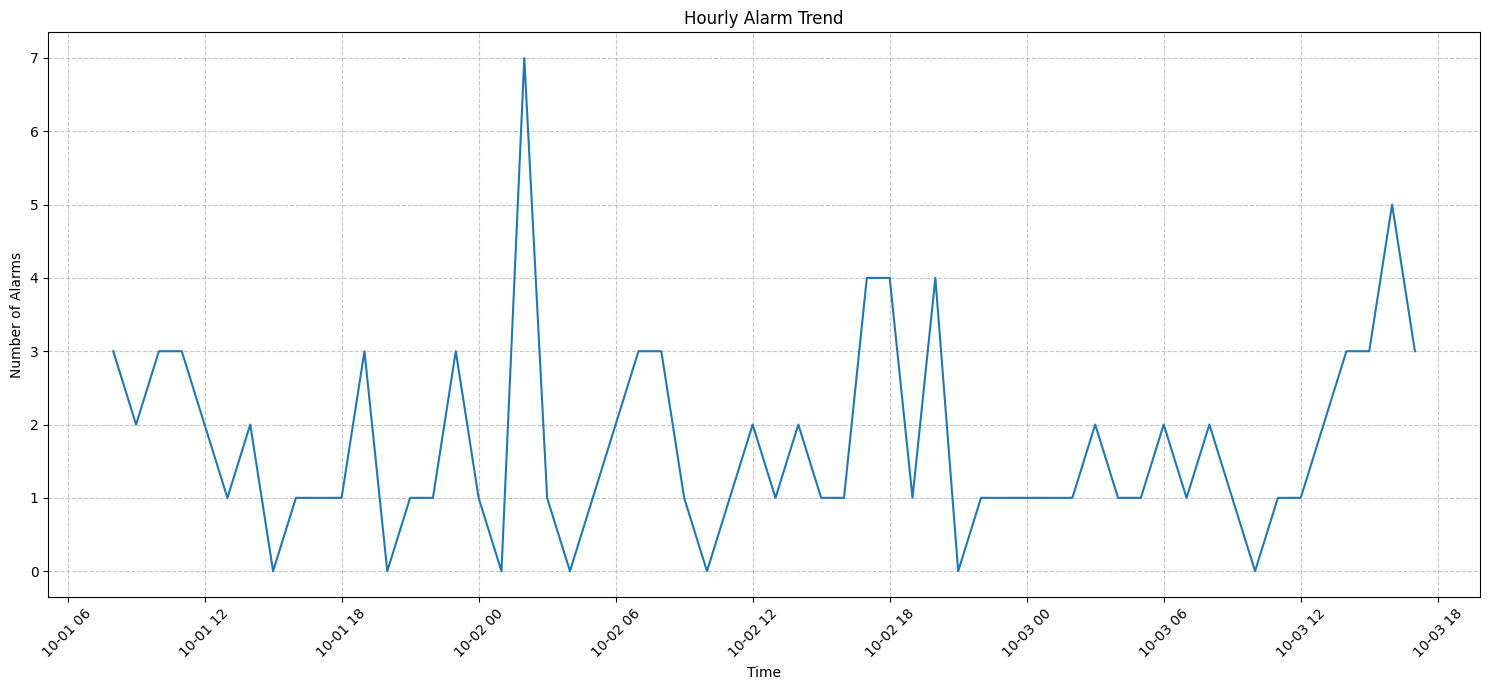

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'timestamp' column is in datetime format (important for resampling)
alarms_df['timestamp'] = pd.to_datetime(alarms_df['timestamp'])

# 3. Alarms Over Time (Line Plot - Hourly Trend)
# Resample to hourly counts
hourly_alarms = alarms_df.set_index('timestamp').resample('h').size().reset_index(name='alarm_count') # Changed 'H' to 'h'

plt.figure(figsize=(15, 7))
sns.lineplot(x='timestamp', y='alarm_count', data=hourly_alarms)
plt.title('Hourly Alarm Trend')
plt.xlabel('Time')
plt.ylabel('Number of Alarms')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This line plot shows the hourly trend of alarms, allowing you to observe patterns, spikes, or quiet periods in your network's activity.

/tmp/ipykernel_9782/2881517260.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='category', data=alarms_df, order=alarms_df['category'].value_counts().index, palette='plasma')


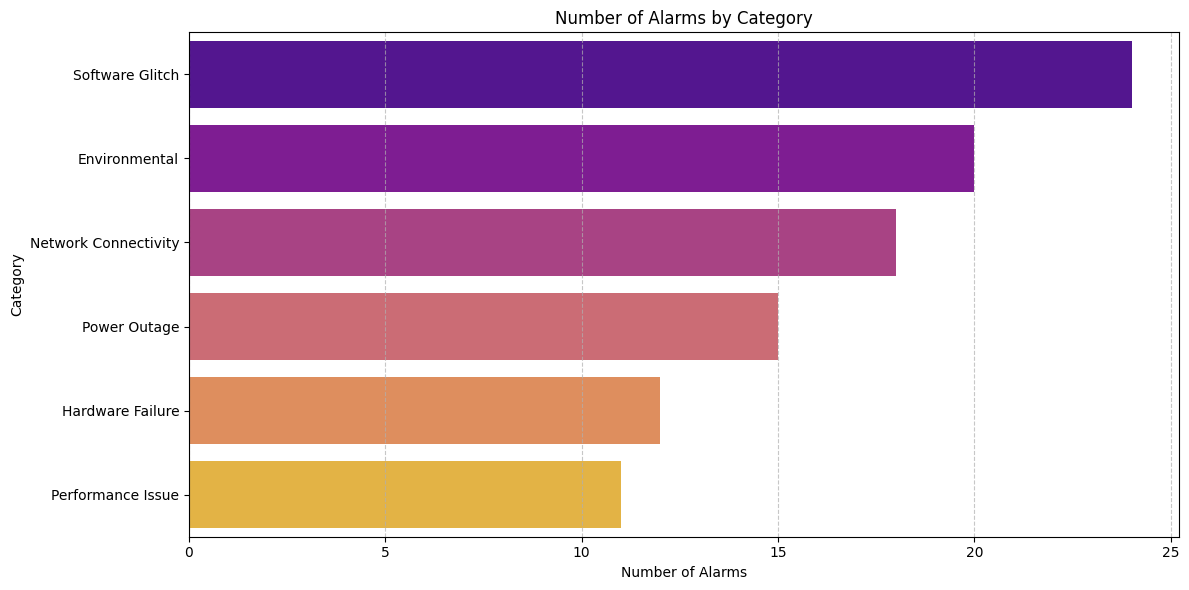

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'timestamp' column is in datetime format (if not already done)
alarms_df['timestamp'] = pd.to_datetime(alarms_df['timestamp'])

# 4. Alarms by Category (Bar Chart)
plt.figure(figsize=(12, 6))
sns.countplot(y='category', data=alarms_df, order=alarms_df['category'].value_counts().index, palette='plasma')
plt.title('Number of Alarms by Category')
plt.xlabel('Number of Alarms')
plt.ylabel('Category')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This bar chart provides an overview of alarm categories, helping you understand the types of issues most prevalent in your system (e.g., network connectivity, hardware failure, performance issues).

### Storing Alarms Data in a Local Database (SQLite)

To store the alarms data persistently and allow for more complex querying, we can use a local database. SQLite is a good choice for this as it's serverless, self-contained, and requires no separate server process. We will store our `alarms_df` DataFrame into an SQLite database.

In [16]:
import sqlite3

# Define the SQLite database file path
db_file = 'telco_alarms.db'

# Connect to SQLite database (creates the file if it doesn't exist)
conn = sqlite3.connect(db_file)

# Save the alarms_df DataFrame to a new table named 'alarms'
# if_exists='replace' will overwrite the table if it already exists
alarms_df.to_sql('alarms', conn, if_exists='replace', index=False)

print(f"Alarms data successfully saved to SQLite database: {db_file}")

# Close the database connection
conn.close()


Alarms data successfully saved to SQLite database: telco_alarms.db


Let's verify that the data has been stored correctly by connecting to the database again and querying the `alarms` table.

In [19]:
# Reconnect to the database
conn = sqlite3.connect(db_file)

# Read data back from the 'alarms' table into a new DataFrame
df_from_db = pd.read_sql('SELECT * FROM alarms LIMIT 100', conn)

print("First 5 rows retrieved from SQLite database:")
display(df_from_db)

# Close the database connection
conn.close()


First 5 rows retrieved from SQLite database:


,timestamp,alarm_id,severity,component,description,status,duration_seconds,category,location,node,llm_input_text,rca_llm_response
0,2023-10-01 08:12:49,ALARM-00020,Critical,Core,Temperature sensor critical on Core rack,Active,2203,Hardware Failure,New York,Node-006,Alarm ID: ALARM-00020. Timestamp: 2023-10-01 0...,[Simulated RCA]: Generic alarm. Further invest...
1,2023-10-01 08:16:56,ALARM-00091,Informational,Power_Supply,Service degradation in Power_Supply region,Active,1257,Environmental,Tokyo,Node-012,Alarm ID: ALARM-00091. Timestamp: 2023-10-01 0...,[Simulated RCA]: Service degradation. Could be...
2,2023-10-01 08:45:47,ALARM-00037,Critical,RAN,Temperature sensor critical on RAN rack,Active,1425,Hardware Failure,Tokyo,Node-003,Alarm ID: ALARM-00037. Timestamp: 2023-10-01 0...,[Simulated RCA]: Generic alarm. Further invest...
3,2023-10-01 09:04:50,ALARM-00052,Informational,Transport,Service degradation in Transport region,Active,3515,Environmental,London,Node-014,Alarm ID: ALARM-00052. Timestamp: 2023-10-01 0...,[Simulated RCA]: Service degradation. Could be...
4,2023-10-01 09:28:31,ALARM-00025,Informational,RAN,Temperature sensor critical on RAN rack,Cleared,3500,Hardware Failure,Tokyo,Node-016,Alarm ID: ALARM-00025. Timestamp: 2023-10-01 0...,[Simulated RCA]: Generic alarm. Further invest...
...,...,...,...,...,...,...,...,...,...,...,...,...
95,2023-10-03 16:57:21,ALARM-00057,Warning,Software,Power failure in Software cabinet,Active,3200,Hardware Failure,New York,Node-011,Alarm ID: ALARM-00057. Timestamp: 2023-10-03 1...,[Simulated RCA]: Power failure detected. Check...
96,2023-10-03 16:58:57,ALARM-00095,Major,Transport,Software error in Transport module,Active,1476,Power Outage,London,Node-004,Alarm ID: ALARM-00095. Timestamp: 2023-10-03 1...,[Simulated RCA]: Generic alarm. Further invest...
97,2023-10-03 17:40:24,ALARM-00059,Minor,Software,Power failure in Software cabinet,Cleared,455,Environmental,New York,Node-017,Alarm ID: ALARM-00059. Timestamp: 2023-10-03 1...,[Simulated RCA]: Power failure detected. Check...
98,2023-10-03 17:44:52,ALARM-00007,Warning,Transport,Service degradation in Transport region,Cleared,3128,Power Outage,Sydney,Node-015,Alarm ID: ALARM-00007. Timestamp: 2023-10-03 1...,[Simulated RCA]: Service degradation. Could be...


### Similarity Search on Alarm Descriptions using LLM Embeddings

To perform a similarity search, we first need to convert our alarm descriptions into numerical representations called embeddings. We will use a pre-trained Sentence Transformer model for this.

In [20]:
# Install the sentence-transformers library
!pip install -U sentence-transformers

In [21]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Load a pre-trained sentence transformer model
# 'all-MiniLM-L6-v2' is a good balance of speed and performance
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings for all alarm descriptions
alarm_descriptions = df_from_db['description'].tolist()
alarm_embeddings = model.encode(alarm_descriptions, show_progress_bar=True)

print(f"Generated embeddings for {len(alarm_embeddings)} alarms. Embedding shape: {alarm_embeddings.shape}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Generated embeddings for 100 alarms. Embedding shape: (100, 384)


Now that we have the embeddings, we can perform a similarity search. Let's define a query and find the most similar alarm descriptions.

In [22]:
# Define a query alarm description
query = "network link problem"

# Generate embedding for the query
query_embedding = model.encode([query])

# Calculate cosine similarity between the query and all alarm embeddings
similarities = cosine_similarity(query_embedding, alarm_embeddings)[0]

# Get the indices of the most similar alarms (descending order)
similar_indices = np.argsort(similarities)[::-1]

print(f"Query: '{query}'\n")
print("Top 5 most similar alarm descriptions:")
for i in similar_indices[:5]:
    print(f"- Similarity: {similarities[i]:.4f} | Alarm ID: {df_from_db.loc[i, 'alarm_id']} | Description: {df_from_db.loc[i, 'description']}")

Query: 'network link problem'

Top 5 most similar alarm descriptions:
- Similarity: 0.4678 | Alarm ID: ALARM-00003 | Description: Link down on Access interface
- Similarity: 0.4678 | Alarm ID: ALARM-00034 | Description: Link down on Access interface
- Similarity: 0.4417 | Alarm ID: ALARM-00012 | Description: Link down on Transport interface
- Similarity: 0.4417 | Alarm ID: ALARM-00014 | Description: Link down on Transport interface
- Similarity: 0.4417 | Alarm ID: ALARM-00046 | Description: Link down on Transport interface


### Create Network Inventory Table

Let's create a new table called `Network Inventory` with dummy data that provides device context. This table will include Device ID, Hostname, IP Address, Vendor, Model, Software Version, Location, and Region. We will store this in our `telco_alarms.db` SQLite database.

In [23]:
import pandas as pd
import numpy as np
import sqlite3

# Number of devices to generate
num_devices = 50

# Generate dummy data for Network Inventory
device_ids = [f'DEV-{i:04d}' for i in range(1, num_devices + 1)]
hostnames = [f'host-{np.random.randint(100, 999)}-{chr(ord('a') + np.random.randint(26))}' for _ in range(num_devices)]
ip_addresses = [f'192.168.{np.random.randint(1, 255)}.{np.random.randint(1, 255)}' for _ in range(num_devices)]
vendors = np.random.choice(['Cisco', 'Juniper', 'Huawei', 'Nokia', 'Ericsson'], num_devices)
models = [f'{vendor}-{np.random.choice(['Router', 'Switch', 'Firewall', 'Server'])}-{np.random.randint(1000, 9999)}' for vendor in vendors]
software_versions = [f'V{np.random.randint(5, 10)}.{np.random.randint(0, 10)}.{np.random.randint(0, 5)}' for _ in range(num_devices)]
locations = np.random.choice(['New York', 'London', 'Tokyo', 'Paris', 'Sydney', 'Mumbai'], num_devices)
regions = np.random.choice(['North America', 'Europe', 'Asia-Pacific'], num_devices, p=[0.4, 0.3, 0.3])

network_inventory_df = pd.DataFrame({
    'Device ID': device_ids,
    'Hostname': hostnames,
    'IP Address': ip_addresses,
    'Vendor': vendors,
    'Model': models,
    'Software Version': software_versions,
    'Location': locations,
    'Region': regions
})

# Display the first few rows of the generated network inventory
print("Generated Network Inventory DataFrame:")
display(network_inventory_df.head())

# Store the network inventory into the SQLite database
db_file = 'telco_alarms.db' # Ensure db_file is defined if not already in scope
conn = sqlite3.connect(db_file)

network_inventory_df.to_sql('network_inventory', conn, if_exists='replace', index=False)

print(f"\nNetwork inventory data successfully saved to SQLite database: {db_file} in table 'network_inventory'")

# Close the database connection
conn.close()

Generated Network Inventory DataFrame:


,Device ID,Hostname,IP Address,Vendor,Model,Software Version,Location,Region
0,DEV-0001,host-210-d,192.168.84.65,Huawei,Huawei-Server-5451,V7.3.0,London,Europe
1,DEV-0002,host-210-v,192.168.63.101,Nokia,Nokia-Server-4876,V9.6.2,London,North America
2,DEV-0003,host-133-o,192.168.73.17,Ericsson,Ericsson-Server-1126,V6.9.2,Sydney,Europe
3,DEV-0004,host-875-h,192.168.9.203,Cisco,Cisco-Switch-9795,V6.0.3,New York,Asia-Pacific
4,DEV-0005,host-468-l,192.168.143.152,Cisco,Cisco-Firewall-7024,V6.6.4,New York,Europe



Network inventory data successfully saved to SQLite database: telco_alarms.db in table 'network_inventory'


Let's verify that the `network_inventory` table has been created and populated correctly in the database.

In [24]:
import sqlite3
import pandas as pd

db_file = 'telco_alarms.db'
conn = sqlite3.connect(db_file)

# Read data back from the 'network_inventory' table
df_network_inventory_from_db = pd.read_sql('SELECT * FROM network_inventory LIMIT 5', conn)

print("First 5 rows retrieved from 'network_inventory' table in SQLite database:")
display(df_network_inventory_from_db)

# Close the database connection
conn.close()

First 5 rows retrieved from 'network_inventory' table in SQLite database:


,Device ID,Hostname,IP Address,Vendor,Model,Software Version,Location,Region
0,DEV-0001,host-210-d,192.168.84.65,Huawei,Huawei-Server-5451,V7.3.0,London,Europe
1,DEV-0002,host-210-v,192.168.63.101,Nokia,Nokia-Server-4876,V9.6.2,London,North America
2,DEV-0003,host-133-o,192.168.73.17,Ericsson,Ericsson-Server-1126,V6.9.2,Sydney,Europe
3,DEV-0004,host-875-h,192.168.9.203,Cisco,Cisco-Switch-9795,V6.0.3,New York,Asia-Pacific
4,DEV-0005,host-468-l,192.168.143.152,Cisco,Cisco-Firewall-7024,V6.6.4,New York,Europe


### Join Network Inventory with Alarms Data

Now, let's join the `network_inventory` data with our `alarms_df` using the common `location` column. This will allow us to enrich the alarm records with device-specific context.

In [25]:
import sqlite3
import pandas as pd

db_file = 'telco_alarms.db'
conn = sqlite3.connect(db_file)

# Load the network_inventory table from the database
network_inventory_df = pd.read_sql('SELECT * FROM network_inventory', conn)

# Close the database connection
conn.close()

# Perform the join operation
# Assuming 'alarms_df' has a 'location' column and 'network_inventory_df' has a 'Location' column
# We'll rename 'Location' in network_inventory_df to 'location' for a cleaner merge
merged_df = pd.merge(alarms_df, network_inventory_df.rename(columns={'Location': 'location'}), on='location', how='left', suffixes=('_alarm', '_device'))

print("Merged DataFrame (first 5 rows) with network inventory context:")
display(merged_df.head())

Merged DataFrame (first 5 rows) with network inventory context:


,timestamp,alarm_id,severity,component,description,status,duration_seconds,category,location,node,llm_input_text,rca_llm_response,Device ID,Hostname,IP Address,Vendor,Model,Software Version,Region
0,2023-10-01 08:12:49,ALARM-00020,Critical,Core,Temperature sensor critical on Core rack,Active,2203,Hardware Failure,New York,Node-006,Alarm ID: ALARM-00020. Timestamp: 2023-10-01 0...,[Simulated RCA]: Generic alarm. Further invest...,DEV-0004,host-875-h,192.168.9.203,Cisco,Cisco-Switch-9795,V6.0.3,Asia-Pacific
1,2023-10-01 08:12:49,ALARM-00020,Critical,Core,Temperature sensor critical on Core rack,Active,2203,Hardware Failure,New York,Node-006,Alarm ID: ALARM-00020. Timestamp: 2023-10-01 0...,[Simulated RCA]: Generic alarm. Further invest...,DEV-0005,host-468-l,192.168.143.152,Cisco,Cisco-Firewall-7024,V6.6.4,Europe
2,2023-10-01 08:12:49,ALARM-00020,Critical,Core,Temperature sensor critical on Core rack,Active,2203,Hardware Failure,New York,Node-006,Alarm ID: ALARM-00020. Timestamp: 2023-10-01 0...,[Simulated RCA]: Generic alarm. Further invest...,DEV-0006,host-694-j,192.168.38.247,Ericsson,Ericsson-Switch-5146,V5.8.2,Europe
3,2023-10-01 08:12:49,ALARM-00020,Critical,Core,Temperature sensor critical on Core rack,Active,2203,Hardware Failure,New York,Node-006,Alarm ID: ALARM-00020. Timestamp: 2023-10-01 0...,[Simulated RCA]: Generic alarm. Further invest...,DEV-0007,host-524-e,192.168.163.94,Ericsson,Ericsson-Router-4368,V7.7.0,North America
4,2023-10-01 08:12:49,ALARM-00020,Critical,Core,Temperature sensor critical on Core rack,Active,2203,Hardware Failure,New York,Node-006,Alarm ID: ALARM-00020. Timestamp: 2023-10-01 0...,[Simulated RCA]: Generic alarm. Further invest...,DEV-0008,host-617-t,192.168.95.49,Huawei,Huawei-Switch-2792,V9.2.2,North America


### Correlation Analysis: Software Versions and Alarm Severity

Let's analyze if there's a correlation between the `Software Version` of a device and the `severity` of alarms it generates. We'll use a stacked bar chart to visualize this relationship.

<Figure size 1500x800 with 0 Axes>

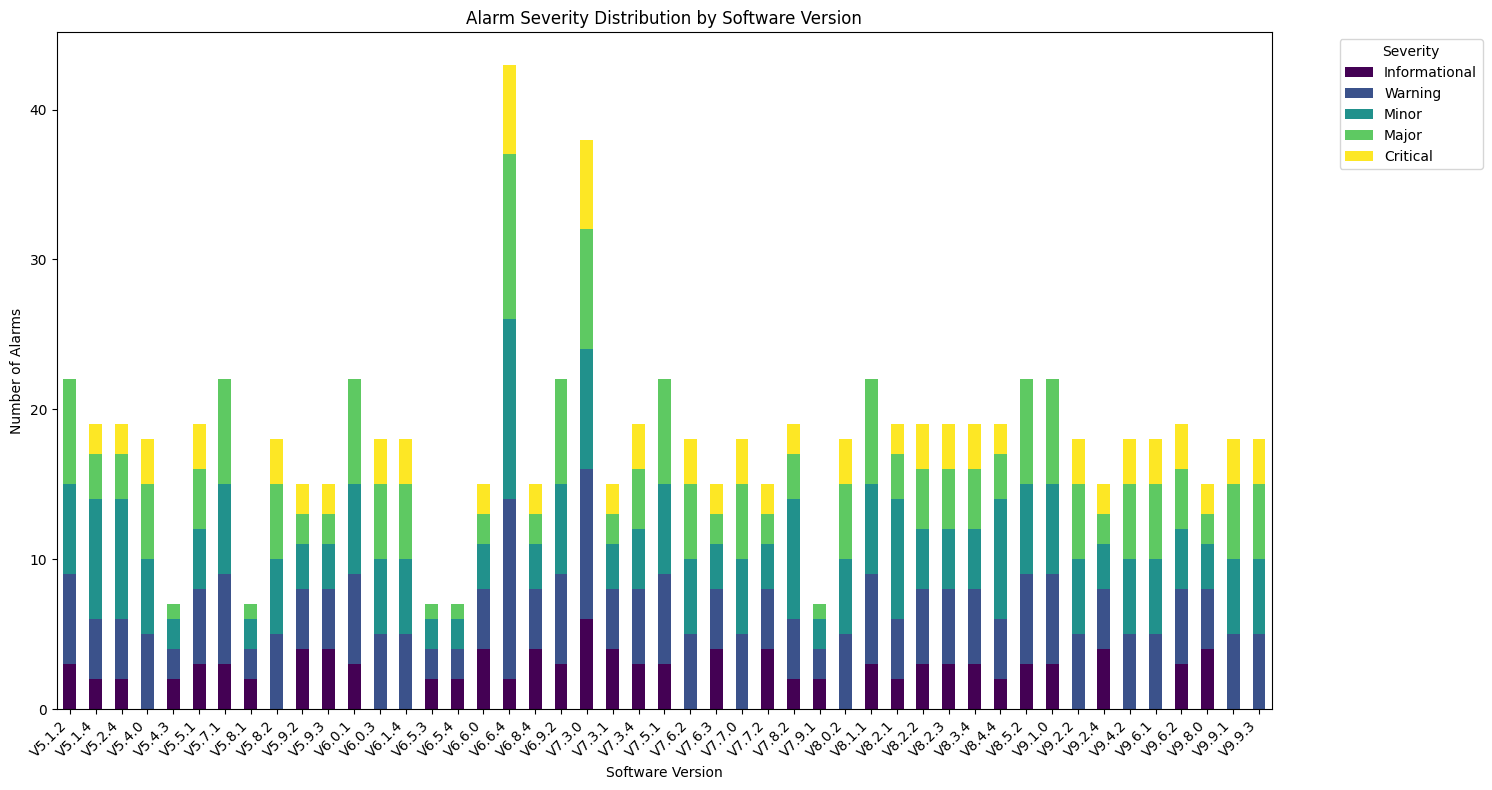

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure severity has a categorical order for consistent plotting
severity_order = ['Informational', 'Warning', 'Minor', 'Major', 'Critical']
merged_df['severity'] = pd.Categorical(merged_df['severity'], categories=severity_order, ordered=True)

# Group by Software Version and Severity, then count occurrences
severity_by_software = merged_df.groupby(['Software Version', 'severity'], observed=False).size().unstack(fill_value=0)

# Sort software versions for better readability if needed (e.g., alphabetically or by total alarms)
severity_by_software = severity_by_software.sort_index()

# Plotting a stacked bar chart
fig = plt.figure(figsize=(15, 8))
severity_by_software.plot(kind='bar', stacked=True, figsize=(15, 8), cmap='viridis')

plt.title('Alarm Severity Distribution by Software Version')
plt.xlabel('Software Version')
plt.ylabel('Number of Alarms')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Severity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Create Service Inventory Table

To facilitate Service Impact Analysis (SIA), we need a `Service Inventory` table that maps network resources to services. This table will contain details such as `Service ID`, `Service Name`, `Service Type`, `Associated Devices`, and `Status`.

In [28]:
import pandas as pd
import numpy as np
import sqlite3

# Number of services to generate
num_services = 20

# Generate dummy data for Service Inventory
service_ids = [f'SVC-{i:03d}' for i in range(1, num_services + 1)]
service_names = [f'Service_{chr(ord('A') + i)}' for i in range(num_services)]
service_types = np.random.choice(['Voice', 'Data', 'Video', 'Messaging', 'Cloud'], num_services)

# Associate devices (from existing network_inventory_df)
# Ensure network_inventory_df is available in the kernel or load it from DB
# For simplicity, we will randomly assign existing Device IDs

# Load network_inventory_df if not in current scope
try:
    if 'network_inventory_df' not in locals() and 'network_inventory_df' not in globals():
        db_file = 'telco_alarms.db'
        conn = sqlite3.connect(db_file)
        network_inventory_df = pd.read_sql('SELECT `Device ID` FROM network_inventory', conn)
        conn.close()
except NameError:
    print("network_inventory_df not found. Please run the previous cells to generate it.")
    network_inventory_df = pd.DataFrame({'Device ID': [f'DEV-{i:04d}' for i in range(1, 51)]}) # Fallback if not found

all_device_ids = network_inventory_df['Device ID'].tolist()

associated_devices = []
for _ in range(num_services):
    # Each service can be associated with 1 to 5 devices
    num_associated = np.random.randint(1, 6)
    associated_devices.append(','.join(np.random.choice(all_device_ids, num_associated, replace=False)))

statuses = np.random.choice(['Operational', 'Degraded', 'Critical'], num_services, p=[0.7, 0.2, 0.1])

service_inventory_df = pd.DataFrame({
    'Service ID': service_ids,
    'Service Name': service_names,
    'Service Type': service_types,
    'Associated Devices': associated_devices,
    'Status': statuses
})

# Display the first few rows of the generated service inventory
print("Generated Service Inventory DataFrame:")
display(service_inventory_df.head())

# Store the service inventory into the SQLite database
db_file = 'telco_alarms.db'
conn = sqlite3.connect(db_file)

service_inventory_df.to_sql('service_inventory', conn, if_exists='replace', index=False)

print(f"\nService inventory data successfully saved to SQLite database: {db_file} in table 'service_inventory'")

# Close the database connection
conn.close()

Generated Service Inventory DataFrame:


,Service ID,Service Name,Service Type,Associated Devices,Status
0,SVC-001,Service_A,Voice,"DEV-0018,DEV-0040",Degraded
1,SVC-002,Service_B,Messaging,"DEV-0004,DEV-0007",Operational
2,SVC-003,Service_C,Cloud,"DEV-0048,DEV-0037,DEV-0020",Critical
3,SVC-004,Service_D,Voice,"DEV-0013,DEV-0008,DEV-0049,DEV-0028",Operational
4,SVC-005,Service_E,Voice,DEV-0010,Operational



Service inventory data successfully saved to SQLite database: telco_alarms.db in table 'service_inventory'


Let's verify that the `service_inventory` table has been created and populated correctly in the database.

In [29]:
import sqlite3
import pandas as pd

db_file = 'telco_alarms.db'
conn = sqlite3.connect(db_file)

# Read data back from the 'service_inventory' table
df_service_inventory_from_db = pd.read_sql('SELECT * FROM service_inventory LIMIT 5', conn)

print("First 5 rows retrieved from 'service_inventory' table in SQLite database:")
display(df_service_inventory_from_db)

# Close the database connection
conn.close()

First 5 rows retrieved from 'service_inventory' table in SQLite database:


,Service ID,Service Name,Service Type,Associated Devices,Status
0,SVC-001,Service_A,Voice,"DEV-0018,DEV-0040",Degraded
1,SVC-002,Service_B,Messaging,"DEV-0004,DEV-0007",Operational
2,SVC-003,Service_C,Cloud,"DEV-0048,DEV-0037,DEV-0020",Critical
3,SVC-004,Service_D,Voice,"DEV-0013,DEV-0008,DEV-0049,DEV-0028",Operational
4,SVC-005,Service_E,Voice,DEV-0010,Operational


### Join Service Inventory with Enriched Alarms Data

Now, let's join the `service_inventory_df` with the `merged_df` (which already contains alarm and network inventory data). This will link alarms to the services they might impact, based on the `Associated Devices` column in the service inventory.

Since a service can be associated with multiple devices, we need to carefully expand the `service_inventory_df` to create a row for each device associated with a service, then join on `Device ID`.

In [33]:
import pandas as pd
import sqlite3

db_file = 'telco_alarms.db'
conn = sqlite3.connect(db_file)

# Load service_inventory and network_inventory (if not already in scope)
# alarms_df and merged_df should already be in scope from previous steps
try:
    if 'service_inventory_df' not in locals() and 'service_inventory_df' not in globals():
        service_inventory_df = pd.read_sql('SELECT * FROM service_inventory', conn)
except NameError:
    print("service_inventory_df not found. Please ensure previous cells are run.")
    # Fallback to load if not in scope (e.g., if notebook restarted)
    service_inventory_df = pd.read_sql('SELECT * FROM service_inventory', conn)

try:
    if 'network_inventory_df' not in locals() and 'network_inventory_df' not in globals():
        network_inventory_df = pd.read_sql('SELECT * FROM network_inventory', conn)
except NameError:
    print("network_inventory_df not found. Please ensure previous cells are run.")
    network_inventory_df = pd.read_sql('SELECT * FROM network_inventory', conn)

conn.close()

# --- Prepare service_inventory_df for joining ---
# Explode the 'Associated Devices' column to have one row per device-service association
service_device_map = service_inventory_df.assign(
    **{'Device ID': service_inventory_df['Associated Devices'].str.split(',')}
).explode('Device ID')

# Trim whitespace from Device IDs if any
service_device_map['Device ID'] = service_device_map['Device ID'].str.strip()

# Select relevant columns from service_device_map for merging
service_device_map = service_device_map[['Service ID', 'Service Name', 'Service Type', 'Device ID', 'Status']]

# --- Perform the join with merged_df ---
# merged_df currently contains alarm data + network inventory data (joined on location)
# We need to join this with the service_device_map on 'Device ID'

# First, ensure 'Device ID' exists in merged_df for the join. It should be there from the network inventory merge.
# However, alarm data might have multiple entries per device ID due to location join strategy.
# We need to consider how to best join. Let's assume merged_df has a 'Device ID' column from the network_inventory join.

# Perform a left join to keep all alarms and add service information where available
final_merged_df = pd.merge(
    merged_df,
    service_device_map, # This now maps one device to one service on a row
    on='Device ID', # Joining on the Device ID column
    how='left',      # Keep all alarms from merged_df
    suffixes=('_alarm_device', '_service')
)

print("Final Merged DataFrame (first 5 rows) with service context:")
display(final_merged_df.head())

print(f"\nShape of the final merged DataFrame: {final_merged_df.shape}")


Final Merged DataFrame (first 5 rows) with service context:


,timestamp,alarm_id,severity,component,description,status,duration_seconds,category,location,node,...,Hostname,IP Address,Vendor,Model,Software Version,Region,Service ID,Service Name,Service Type,Status
0,2023-10-01 08:12:49,ALARM-00020,Critical,Core,Temperature sensor critical on Core rack,Active,2203,Hardware Failure,New York,Node-006,...,host-875-h,192.168.9.203,Cisco,Cisco-Switch-9795,V6.0.3,Asia-Pacific,SVC-002,Service_B,Messaging,Operational
1,2023-10-01 08:12:49,ALARM-00020,Critical,Core,Temperature sensor critical on Core rack,Active,2203,Hardware Failure,New York,Node-006,...,host-468-l,192.168.143.152,Cisco,Cisco-Firewall-7024,V6.6.4,Europe,SVC-006,Service_F,Video,Operational
2,2023-10-01 08:12:49,ALARM-00020,Critical,Core,Temperature sensor critical on Core rack,Active,2203,Hardware Failure,New York,Node-006,...,host-694-j,192.168.38.247,Ericsson,Ericsson-Switch-5146,V5.8.2,Europe,SVC-011,Service_K,Cloud,Critical
3,2023-10-01 08:12:49,ALARM-00020,Critical,Core,Temperature sensor critical on Core rack,Active,2203,Hardware Failure,New York,Node-006,...,host-694-j,192.168.38.247,Ericsson,Ericsson-Switch-5146,V5.8.2,Europe,SVC-014,Service_N,Cloud,Degraded
4,2023-10-01 08:12:49,ALARM-00020,Critical,Core,Temperature sensor critical on Core rack,Active,2203,Hardware Failure,New York,Node-006,...,host-694-j,192.168.38.247,Ericsson,Ericsson-Switch-5146,V5.8.2,Europe,SVC-020,Service_T,Video,Operational



Shape of the final merged DataFrame: (1282, 23)


This `final_merged_df` now contains your alarm data enriched with both network device details and associated service information, which is crucial for Service Impact Analysis. Each alarm can now be directly linked to the services that might be affected by it.

### Join Site Master Data with Enriched Alarms Data

To enable geographic impact analysis and create regional dashboards, we will now join the `site_master_df` with the `final_merged_df` (which contains alarm, network inventory, and service data). We will join on the `location` column to add `Site ID`, `Site Name`, `Region`, `Latitude`, and `Longitude` to our alarms.

In [44]:
import pandas as pd
import sqlite3

db_file = 'telco_alarms.db'
conn = sqlite3.connect(db_file)

# Load service_inventory and network_inventory (if not already in scope)
# alarms_df and merged_df should already be in scope from previous steps
try:
    if 'service_inventory_df' not in locals() and 'service_inventory_df' not in globals():
        service_inventory_df = pd.read_sql('SELECT * FROM service_inventory', conn)
except NameError:
    print("service_inventory_df not found. Please ensure previous cells are run.")
    # Fallback to load if not in scope (e.g., if notebook restarted)
    service_inventory_df = pd.read_sql('SELECT * FROM service_inventory', conn)

try:
    if 'network_inventory_df' not in locals() and 'network_inventory_df' not in globals():
        network_inventory_df = pd.read_sql('SELECT * FROM network_inventory', conn)
except NameError:
    print("network_inventory_df not found. Please ensure previous cells are run.")
    network_inventory_df = pd.read_sql('SELECT * FROM network_inventory', conn)

# Re-load alarms_df as well to ensure it's up-to-date for merging if necessary
# Assuming alarms_df and merged_df are correctly updated by previous steps for 'final_merged_df'
# Load site_master_df if not already in scope
try:
    if 'site_master_df' not in locals() and 'site_master_df' not in globals():
        site_master_df = pd.read_sql('SELECT * FROM site_master_data', conn)
except NameError:
    print("site_master_df not found. Please ensure previous cells are run.")
    site_master_df = pd.read_sql('SELECT * FROM site_master_data', conn)

conn.close()

# Ensure 'Device ID' exists in network_inventory_df
# Re-create merged_df and final_merged_df to ensure they reflect the updated network_inventory
# First, re-load alarms_df to ensure it's the base for merging
alarms_df = pd.read_csv('telco_oss_alarms.csv')
alarms_df['timestamp'] = pd.to_datetime(alarms_df['timestamp'])

# --- Filter alarms_df to include only UK/NI locations as per the restricted site_master_data ---
uk_ni_locations = site_master_df['Site Name'].unique()
alarms_df_filtered = alarms_df[alarms_df['location'].isin(uk_ni_locations)]

merged_df = pd.merge(alarms_df_filtered, network_inventory_df.rename(columns={'Location': 'location'}), on='location', how='left', suffixes=('_alarm', '_device'))

# --- Prepare service_inventory_df for joining ---
# Explode the 'Associated Devices' column to have one row per device-service association
service_device_map = service_inventory_df.assign(
    **{'Device ID': service_inventory_df['Associated Devices'].str.split(',')}
).explode('Device ID')

# Trim whitespace from Device IDs if any
service_device_map['Device ID'] = service_device_map['Device ID'].str.strip()

# Select relevant columns from service_device_map for merging
service_device_map = service_device_map[['Service ID', 'Service Name', 'Service Type', 'Device ID', 'Status']]

# Perform a left join to keep all alarms and add service information where available
final_merged_df = pd.merge(
    merged_df,
    service_device_map,
    on='Device ID',
    how='left',
    suffixes=('_alarm_device', '_service')
)


# The current site_master_df has 'Site Name' which is the location itself in this updated version.
# We need to map 'Site Name' from site_master_df to 'location' in final_merged_df.
site_master_for_merge = site_master_df.copy()
site_master_for_merge['location'] = site_master_for_merge['Site Name'] # Use Site Name directly as location

# Perform a left join to keep all alarms and add site information where available
# We will use the 'location' column from final_merged_df and the newly created 'location' in site_master_for_merge
ultimate_merged_df = pd.merge(
    final_merged_df,
    site_master_for_merge[['Site ID', 'Site Name', 'Region', 'Latitude', 'Longitude', 'location']],
    on='location', # Joining on the location column
    how='left',    # Keep all alarms from final_merged_df
    suffixes=('_alarm', '_site')
)

print("Ultimate Merged DataFrame (first 5 rows) with updated site context:")
display(ultimate_merged_df.head())

print(f"\nShape of the ultimate merged DataFrame: {ultimate_merged_df.shape}")

Ultimate Merged DataFrame (first 5 rows) with updated site context:


,timestamp,alarm_id,severity,component,description,status,duration_seconds,category,location,node,...,Region_alarm,Service ID,Service Name,Service Type,Status,Site ID,Site Name,Region_site,Latitude,Longitude
0,2023-10-01 09:04:50,ALARM-00052,Informational,Transport,Service degradation in Transport region,Active,3515,Environmental,London,Node-014,...,Europe,SVC-007,Service_G,Cloud,Critical,SITE-001,London,England,51.5074,-0.1278
1,2023-10-01 09:04:50,ALARM-00052,Informational,Transport,Service degradation in Transport region,Active,3515,Environmental,London,Node-014,...,Europe,SVC-013,Service_M,Voice,Degraded,SITE-001,London,England,51.5074,-0.1278
2,2023-10-01 09:04:50,ALARM-00052,Informational,Transport,Service degradation in Transport region,Active,3515,Environmental,London,Node-014,...,North America,NaN,NaN,NaN,NaN,SITE-001,London,England,51.5074,-0.1278
3,2023-10-01 09:04:50,ALARM-00052,Informational,Transport,Service degradation in Transport region,Active,3515,Environmental,London,Node-014,...,North America,SVC-010,Service_J,Data,Operational,SITE-001,London,England,51.5074,-0.1278
4,2023-10-01 09:04:50,ALARM-00052,Informational,Transport,Service degradation in Transport region,Active,3515,Environmental,London,Node-014,...,North America,SVC-016,Service_P,Voice,Operational,SITE-001,London,England,51.5074,-0.1278



Shape of the ultimate merged DataFrame: (209, 26)


This `ultimate_merged_df` now represents your most comprehensive dataset, including alarm details, network device context, service impact information, and geographic location data. You are now equipped for advanced analyses such as:

*   **Geographic Impact Analysis:** Identify alarm hotspots on a map.
*   **Service-Level Reporting:** Filter alarms by service and understand service health.
*   **Cross-Domain Correlation:** Analyze how different layers (network, service, location) interact during incidents.

What kind of analysis or visualization would you like to perform next using this rich dataset?

### Create SLA Catalog Table

Let's create an `SLA Catalog` table, which will include customer information, associated services, and various SLA targets (Availability, Latency) along with penalties. This table will leverage the `Service ID` from our `service_inventory` to establish relationships.

In [45]:
import pandas as pd
import numpy as np
import sqlite3

db_file = 'telco_alarms.db'
conn = sqlite3.connect(db_file)

# Load existing service_inventory to ensure valid service IDs
service_inventory_df = pd.read_sql('SELECT `Service ID`, `Service Name` FROM service_inventory', conn)

num_slas = 30 # Number of SLA entries to generate

# Generate dummy data for SLA Catalog
customers = [f'Customer_{i:02d}' for i in range(1, num_slas + 1)]

# Ensure services come from the existing service inventory
service_ids = np.random.choice(service_inventory_df['Service ID'].unique(), num_slas, replace=True)

# Map Service ID to Service Name for the 'Service' column
service_names_map = service_inventory_df.set_index('Service ID')['Service Name'].to_dict()
services = [service_names_map.get(sid, 'Unknown Service') for sid in service_ids]

availability_targets = np.random.choice(['99.9%', '99.95%', '99.99%', '99.999%'], num_slas)
latency_targets = np.random.choice(['10ms', '20ms', '50ms', '100ms'], num_slas)
penalties = np.random.choice(['Credit', 'Service Upgrade', 'Discount'], num_slas)

sla_catalog_df = pd.DataFrame({
    'Customer': customers,
    'Service ID': service_ids, # Keep Service ID for linking
    'Service': services,
    'Availability Target': availability_targets,
    'Latency Target': latency_targets,
    'Penalty': penalties
})

# Display the first few rows of the generated SLA Catalog
print("Generated SLA Catalog DataFrame:")
display(sla_catalog_df.head())

# Store the SLA Catalog into the SQLite database
sla_catalog_df.to_sql('sla_catalog', conn, if_exists='replace', index=False)

print(f"\nSLA catalog data successfully saved to SQLite database: {db_file} in table 'sla_catalog'")

# Close the database connection
conn.close()

Generated SLA Catalog DataFrame:


,Customer,Service ID,Service,Availability Target,Latency Target,Penalty
0,Customer_01,SVC-002,Service_B,99.95%,20ms,Discount
1,Customer_02,SVC-008,Service_H,99.9%,100ms,Service Upgrade
2,Customer_03,SVC-015,Service_O,99.99%,10ms,Discount
3,Customer_04,SVC-007,Service_G,99.99%,100ms,Discount
4,Customer_05,SVC-006,Service_F,99.999%,100ms,Discount



SLA catalog data successfully saved to SQLite database: telco_alarms.db in table 'sla_catalog'


Let's verify that the `sla_catalog` table has been created and populated correctly, and check its row count along with other tables.

In [46]:
import sqlite3
import pandas as pd

db_file = 'telco_alarms.db'
conn = sqlite3.connect(db_file)

cursor = conn.cursor()

# Get a list of all tables in the database
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()

print("Row counts for each table in 'telco_alarms.db' after SLA Catalog creation:")
for table_name_tuple in tables:
    table_name = table_name_tuple[0]
    # Execute a SELECT COUNT(*) query for each table
    cursor.execute(f"SELECT COUNT(*) FROM {table_name}")
    row_count = cursor.fetchone()[0]
    print(f"- Table '{table_name}': {row_count} rows")

conn.close()

Row counts for each table in 'telco_alarms.db' after SLA Catalog creation:
- Table 'alarms': 100 rows
- Table 'service_inventory': 20 rows
- Table 'network_inventory': 100 rows
- Table 'site_master_data': 107 rows
- Table 'sla_catalog': 30 rows


### Create Site/Location Master Data Table

For geographic impact analysis and regional dashboards, let's create a `Site Master Data` table. This table will include `Site ID`, `Site Name`, `Region`, `Latitude`, and `Longitude`.

In [42]:
import pandas as pd
import numpy as np
import sqlite3

# Define specific locations within the UK and Northern Ireland
# Restricting to only UK and Northern Ireland regions as requested by the user
unique_locations = [
    {'name': 'London', 'region': 'England', 'lat': 51.5074, 'lon': -0.1278},
    {'name': 'Manchester', 'region': 'England', 'lat': 53.4808, 'lon': -2.2426},
    {'name': 'Birmingham', 'region': 'England', 'lat': 52.4862, 'lon': -1.8904},
    {'name': 'Glasgow', 'region': 'Scotland', 'lat': 55.8642, 'lon': -4.2518},
    {'name': 'Edinburgh', 'region': 'Scotland', 'lat': 55.9533, 'lon': -3.1883},
    {'name': 'Cardiff', 'region': 'Wales', 'lat': 51.4816, 'lon': -3.1791},
    {'name': 'Belfast', 'region': 'Northern Ireland', 'lat': 54.5973, 'lon': -5.9301}
]

num_sites = len(unique_locations)

site_ids = [f'SITE-{i:03d}' for i in range(1, num_sites + 1)]
site_names = [loc['name'] for loc in unique_locations]
regions = [loc['region'] for loc in unique_locations]
latitudes = [loc['lat'] for loc in unique_locations]
longitudes = [loc['lon'] for loc in unique_locations]

site_master_df = pd.DataFrame({
    'Site ID': site_ids,
    'Site Name': site_names,
    'Region': regions,
    'Latitude': latitudes,
    'Longitude': longitudes
})

# Display the first few rows of the generated Site Master Data
print("Generated Site Master Data DataFrame (UK and Northern Ireland only):")
display(site_master_df.head())

# Store the site master data into the SQLite database
db_file = 'telco_alarms.db'
conn = sqlite3.connect(db_file)

site_master_df.to_sql('site_master_data', conn, if_exists='replace', index=False)

print(f"\nSite master data successfully saved to SQLite database: {db_file} in table 'site_master_data'")

# Close the database connection
conn.close()

Generated Site Master Data DataFrame (UK and Northern Ireland only):


,Site ID,Site Name,Region,Latitude,Longitude
0,SITE-001,London,England,51.5074,-0.1278
1,SITE-002,Manchester,England,53.4808,-2.2426
2,SITE-003,Birmingham,England,52.4862,-1.8904
3,SITE-004,Glasgow,Scotland,55.8642,-4.2518
4,SITE-005,Edinburgh,Scotland,55.9533,-3.1883



Site master data successfully saved to SQLite database: telco_alarms.db in table 'site_master_data'


Let's verify that the `site_master_data` table has been created and populated correctly in the database.

In [32]:
import sqlite3
import pandas as pd

db_file = 'telco_alarms.db'
conn = sqlite3.connect(db_file)

# Read data back from the 'site_master_data' table
df_site_master_from_db = pd.read_sql('SELECT * FROM site_master_data LIMIT 5', conn)

print("First 5 rows retrieved from 'site_master_data' table in SQLite database:")
display(df_site_master_from_db)

# Close the database connection
conn.close()

First 5 rows retrieved from 'site_master_data' table in SQLite database:


,Site ID,Site Name,Region,Latitude,Longitude
0,SITE-001,Site New York,North America,21.9132,-110.7516
1,SITE-002,Site Tokyo,Europe,21.5209,12.2306
2,SITE-003,Site London,Europe,49.8483,-19.2252
3,SITE-004,Site Mumbai,North America,46.3614,0.1062
4,SITE-005,Site Paris,North America,52.0852,137.8130


In [37]:
import sqlite3
import pandas as pd

db_file = 'telco_alarms.db'
conn = sqlite3.connect(db_file)

cursor = conn.cursor()

# Get a list of all tables in the database
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()

print("Row counts for each table in 'telco_alarms.db':")
for table_name_tuple in tables:
    table_name = table_name_tuple[0]
    # Execute a SELECT COUNT(*) query for each table
    cursor.execute(f"SELECT COUNT(*) FROM {table_name}")
    row_count = cursor.fetchone()[0]
    print(f"- Table '{table_name}': {row_count} rows")

conn.close()

Row counts for each table in 'telco_alarms.db':
- Table 'alarms': 100 rows
- Table 'network_inventory': 50 rows
- Table 'service_inventory': 20 rows
- Table 'site_master_data': 6 rows


### Extending Network Inventory Data

Let's add 50 more rows to the `network_inventory` table.

In [38]:
import pandas as pd
import numpy as np
import sqlite3

db_file = 'telco_alarms.db'
conn = sqlite3.connect(db_file)

# Load existing network_inventory_df
existing_network_inventory_df = pd.read_sql('SELECT * FROM network_inventory', conn)

# Number of new devices to generate
num_new_devices = 50
current_num_devices = len(existing_network_inventory_df)

# Generate dummy data for new Network Inventory entries
new_device_ids = [f'DEV-{i:04d}' for i in range(current_num_devices + 1, current_num_devices + num_new_devices + 1)]
new_hostnames = [f'host-{np.random.randint(100, 999)}-{chr(ord('a') + np.random.randint(26))}' for _ in range(num_new_devices)]
new_ip_addresses = [f'192.168.{np.random.randint(1, 255)}.{np.random.randint(1, 255)}' for _ in range(num_new_devices)]
new_vendors = np.random.choice(['Cisco', 'Juniper', 'Huawei', 'Nokia', 'Ericsson', 'Arista', 'Dell'], num_new_devices)
new_models = [f'{vendor}-{np.random.choice(['Router', 'Switch', 'Firewall', 'Server', 'LoadBalancer'])}-{np.random.randint(1000, 9999)}' for vendor in new_vendors]
new_software_versions = [f'V{np.random.randint(5, 12)}.{np.random.randint(0, 10)}.{np.random.randint(0, 5)}' for _ in range(num_new_devices)]
new_locations = np.random.choice(['New York', 'London', 'Tokyo', 'Paris', 'Sydney', 'Mumbai', 'Singapore', 'Frankfurt', 'São Paulo', 'Cape Town', 'Dubai', 'Toronto'], num_new_devices)
new_regions = np.random.choice(['North America', 'Europe', 'Asia-Pacific', 'South America', 'Africa', 'Middle East', 'Oceania'], num_new_devices, p=[0.25, 0.25, 0.2, 0.1, 0.05, 0.05, 0.1])

new_network_inventory_df = pd.DataFrame({
    'Device ID': new_device_ids,
    'Hostname': new_hostnames,
    'IP Address': new_ip_addresses,
    'Vendor': new_vendors,
    'Model': new_models,
    'Software Version': new_software_versions,
    'Location': new_locations,
    'Region': new_regions
})

# Concatenate existing and new data
updated_network_inventory_df = pd.concat([existing_network_inventory_df, new_network_inventory_df], ignore_index=True)

# Store the updated network inventory back into the SQLite database
updated_network_inventory_df.to_sql('network_inventory', conn, if_exists='replace', index=False)

print(f"Added {num_new_devices} new devices. Total network inventory rows: {len(updated_network_inventory_df)}")
print(f"Updated network inventory data successfully saved to SQLite database: {db_file} in table 'network_inventory'")

# Close the database connection
conn.close()

# Display the head and tail of the updated DataFrame
print("\nUpdated Network Inventory DataFrame (head):")
display(updated_network_inventory_df.head())
print("\nUpdated Network Inventory DataFrame (tail):")
display(updated_network_inventory_df.tail())

Added 50 new devices. Total network inventory rows: 100
Updated network inventory data successfully saved to SQLite database: telco_alarms.db in table 'network_inventory'

Updated Network Inventory DataFrame (head):


,Device ID,Hostname,IP Address,Vendor,Model,Software Version,Location,Region
0,DEV-0001,host-210-d,192.168.84.65,Huawei,Huawei-Server-5451,V7.3.0,London,Europe
1,DEV-0002,host-210-v,192.168.63.101,Nokia,Nokia-Server-4876,V9.6.2,London,North America
2,DEV-0003,host-133-o,192.168.73.17,Ericsson,Ericsson-Server-1126,V6.9.2,Sydney,Europe
3,DEV-0004,host-875-h,192.168.9.203,Cisco,Cisco-Switch-9795,V6.0.3,New York,Asia-Pacific
4,DEV-0005,host-468-l,192.168.143.152,Cisco,Cisco-Firewall-7024,V6.6.4,New York,Europe



Updated Network Inventory DataFrame (tail):


,Device ID,Hostname,IP Address,Vendor,Model,Software Version,Location,Region
95,DEV-0096,host-337-g,192.168.223.247,Arista,Arista-Switch-3539,V9.8.2,London,Africa
96,DEV-0097,host-762-l,192.168.70.56,Ericsson,Ericsson-Router-5260,V5.3.0,London,Europe
97,DEV-0098,host-835-k,192.168.211.101,Nokia,Nokia-Switch-7164,V8.1.1,Tokyo,Middle East
98,DEV-0099,host-355-v,192.168.186.132,Arista,Arista-Switch-4670,V10.4.2,Frankfurt,North America
99,DEV-0100,host-761-k,192.168.111.125,Juniper,Juniper-Switch-9100,V9.8.3,Frankfurt,South America


### Extending Site Master Data

Now, let's add 100 more rows to the `site_master_data` table, expanding its geographic coverage.

In [43]:
import pandas as pd
import numpy as np
import sqlite3

db_file = 'telco_alarms.db'
conn = sqlite3.connect(db_file)

# Load existing site_master_df
existing_site_master_df = pd.read_sql('SELECT * FROM site_master_data', conn)

# Number of new sites to generate
num_new_sites = 100
current_num_sites = len(existing_site_master_df)

# Define locations and regions strictly within the UK and Northern Ireland
# to ensure the condition is met for newly added rows
wider_locations = [
    'London', 'Manchester', 'Birmingham', 'Glasgow', 'Edinburgh',
    'Cardiff', 'Belfast', 'Liverpool', 'Leeds', 'Bristol',
    'Sheffield', 'Nottingham', 'Newcastle', 'Southampton', 'Coventry',
    'Leicester', 'Brighton', 'Plymouth', 'Hull', 'Stoke-on-Trent',
    'Derby', 'Portsmouth', 'Wolverhampton', 'Aberdeen', 'Dundee',
    'Swansea', 'Newport', 'Lisburn', 'Londonderry'
]

wider_regions = [
    'England', 'Scotland', 'Wales', 'Northern Ireland'
]

new_site_ids = [f'SITE-{i:03d}' for i in range(current_num_sites + 1, current_num_sites + num_new_sites + 1)]
new_site_names = np.random.choice(wider_locations, num_new_sites, replace=True) # Allow repeats for city names, but Site ID is unique
new_regions = np.random.choice(wider_regions, num_new_sites, p=[0.7, 0.15, 0.1, 0.05], replace=True) # Distribute based on population/area
new_latitudes = np.random.uniform(49.9, 60.9, num_new_sites) # Approximate latitude range for UK/NI
new_longitudes = np.random.uniform(-10.8, 1.8, num_new_sites) # Approximate longitude range for UK/NI

new_site_master_df = pd.DataFrame({
    'Site ID': new_site_ids,
    'Site Name': new_site_names,
    'Region': new_regions,
    'Latitude': new_latitudes,
    'Longitude': new_longitudes
})

# Concatenate existing and new data
updated_site_master_df = pd.concat([existing_site_master_df, new_site_master_df], ignore_index=True)

# Store the updated site master data back into the SQLite database
updated_site_master_df.to_sql('site_master_data', conn, if_exists='replace', index=False)

print(f"Added {num_new_sites} new sites. Total site master data rows: {len(updated_site_master_df)}")
print(f"Updated site master data successfully saved to SQLite database: {db_file} in table 'site_master_data'")

# Close the database connection
conn.close()

# Display the head and tail of the updated DataFrame
print("\nUpdated Site Master Data DataFrame (head):")
display(updated_site_master_df.head())
print("\nUpdated Site Master Data DataFrame (tail):")
display(updated_site_master_df.tail())

Added 100 new sites. Total site master data rows: 107
Updated site master data successfully saved to SQLite database: telco_alarms.db in table 'site_master_data'

Updated Site Master Data DataFrame (head):


,Site ID,Site Name,Region,Latitude,Longitude
0,SITE-001,London,England,51.5074,-0.1278
1,SITE-002,Manchester,England,53.4808,-2.2426
2,SITE-003,Birmingham,England,52.4862,-1.8904
3,SITE-004,Glasgow,Scotland,55.8642,-4.2518
4,SITE-005,Edinburgh,Scotland,55.9533,-3.1883



Updated Site Master Data DataFrame (tail):


,Site ID,Site Name,Region,Latitude,Longitude
102,SITE-103,Leeds,England,56.742435,-0.962779
103,SITE-104,Birmingham,England,60.816865,-1.873030
104,SITE-105,Coventry,Northern Ireland,54.149555,-8.631676
105,SITE-106,Leicester,England,56.212254,1.452492
106,SITE-107,Plymouth,Wales,54.471643,-5.144948


### Verify Updated Table Row Counts

Let's verify the new row counts for all tables in the database.

In [47]:
import sqlite3
import pandas as pd

db_file = 'telco_alarms.db'
conn = sqlite3.connect(db_file)

cursor = conn.cursor()

# Get a list of all tables in the database
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()

print("Row counts and first 5 rows for each table in 'telco_alarms.db' after updates:")
for table_name_tuple in tables:
    table_name = table_name_tuple[0]
    # Execute a SELECT COUNT(*) query for each table
    cursor.execute(f"SELECT COUNT(*) FROM {table_name}")
    row_count = cursor.fetchone()[0]
    print(f"\n- Table '{table_name}': {row_count} rows")

    # Display first 5 rows of the table
    df_table = pd.read_sql(f'SELECT * FROM {table_name} LIMIT 5', conn)
    display(df_table)

conn.close()

Row counts and first 5 rows for each table in 'telco_alarms.db' after updates:

- Table 'alarms': 100 rows


,timestamp,alarm_id,severity,component,description,status,duration_seconds,category,location,node,llm_input_text,rca_llm_response
0,2023-10-01 08:12:49,ALARM-00020,Critical,Core,Temperature sensor critical on Core rack,Active,2203,Hardware Failure,New York,Node-006,Alarm ID: ALARM-00020. Timestamp: 2023-10-01 0...,[Simulated RCA]: Generic alarm. Further invest...
1,2023-10-01 08:16:56,ALARM-00091,Informational,Power_Supply,Service degradation in Power_Supply region,Active,1257,Environmental,Tokyo,Node-012,Alarm ID: ALARM-00091. Timestamp: 2023-10-01 0...,[Simulated RCA]: Service degradation. Could be...
2,2023-10-01 08:45:47,ALARM-00037,Critical,RAN,Temperature sensor critical on RAN rack,Active,1425,Hardware Failure,Tokyo,Node-003,Alarm ID: ALARM-00037. Timestamp: 2023-10-01 0...,[Simulated RCA]: Generic alarm. Further invest...
3,2023-10-01 09:04:50,ALARM-00052,Informational,Transport,Service degradation in Transport region,Active,3515,Environmental,London,Node-014,Alarm ID: ALARM-00052. Timestamp: 2023-10-01 0...,[Simulated RCA]: Service degradation. Could be...
4,2023-10-01 09:28:31,ALARM-00025,Informational,RAN,Temperature sensor critical on RAN rack,Cleared,3500,Hardware Failure,Tokyo,Node-016,Alarm ID: ALARM-00025. Timestamp: 2023-10-01 0...,[Simulated RCA]: Generic alarm. Further invest...



- Table 'service_inventory': 20 rows


,Service ID,Service Name,Service Type,Associated Devices,Status
0,SVC-001,Service_A,Voice,"DEV-0018,DEV-0040",Degraded
1,SVC-002,Service_B,Messaging,"DEV-0004,DEV-0007",Operational
2,SVC-003,Service_C,Cloud,"DEV-0048,DEV-0037,DEV-0020",Critical
3,SVC-004,Service_D,Voice,"DEV-0013,DEV-0008,DEV-0049,DEV-0028",Operational
4,SVC-005,Service_E,Voice,DEV-0010,Operational



- Table 'network_inventory': 100 rows


,Device ID,Hostname,IP Address,Vendor,Model,Software Version,Location,Region
0,DEV-0001,host-210-d,192.168.84.65,Huawei,Huawei-Server-5451,V7.3.0,London,Europe
1,DEV-0002,host-210-v,192.168.63.101,Nokia,Nokia-Server-4876,V9.6.2,London,North America
2,DEV-0003,host-133-o,192.168.73.17,Ericsson,Ericsson-Server-1126,V6.9.2,Sydney,Europe
3,DEV-0004,host-875-h,192.168.9.203,Cisco,Cisco-Switch-9795,V6.0.3,New York,Asia-Pacific
4,DEV-0005,host-468-l,192.168.143.152,Cisco,Cisco-Firewall-7024,V6.6.4,New York,Europe



- Table 'site_master_data': 107 rows


,Site ID,Site Name,Region,Latitude,Longitude
0,SITE-001,London,England,51.5074,-0.1278
1,SITE-002,Manchester,England,53.4808,-2.2426
2,SITE-003,Birmingham,England,52.4862,-1.8904
3,SITE-004,Glasgow,Scotland,55.8642,-4.2518
4,SITE-005,Edinburgh,Scotland,55.9533,-3.1883



- Table 'sla_catalog': 30 rows


,Customer,Service ID,Service,Availability Target,Latency Target,Penalty
0,Customer_01,SVC-002,Service_B,99.95%,20ms,Discount
1,Customer_02,SVC-008,Service_H,99.9%,100ms,Service Upgrade
2,Customer_03,SVC-015,Service_O,99.99%,10ms,Discount
3,Customer_04,SVC-007,Service_G,99.99%,100ms,Discount
4,Customer_05,SVC-006,Service_F,99.999%,100ms,Discount
